# Proyecto: Análisis de Ventas de Supermercado

## Introducción

En este proyecto se realizará un análisis exploratorio de datos (EDA) utilizando información de ventas de un supermercado.

El objetivo principal es analizar el comportamiento de ventas, clientes y categorías de productos para identificar patrones comerciales y generar insights de negocio útiles para la toma de decisiones.

El análisis estará enfocado en comprender:

- El rendimiento de las sucursales
- Las categorías de productos más relevantes
- El comportamiento de compra de los clientes
- Las diferencias entre tipos de clientes
- La relación entre precios, cantidades y ventas totales
- El impacto de los puntos de recompensa en las compras

---

## Objetivos del Proyecto

### Objetivo General

Realizar un análisis exploratorio del dataset de ventas de supermercado para identificar patrones de consumo, comportamiento de clientes y oportunidades de negocio.

---

### Objetivos Específicos

- Analizar las ventas totales del supermercado
- Identificar las sucursales con mejor desempeño
- Evaluar las categorías de productos más vendidas
- Analizar diferencias entre tipos de clientes y género
- Estudiar la relación entre cantidad comprada y ventas
- Explorar el comportamiento de los puntos de recompensa
- Generar insights comerciales basados en los datos



In [106]:
# ==================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, mannwhitneyu

# Configuración visual

plt.style.use('ggplot')

# Mostrar todas las columnas

pd.set_option('display.max_columns', None)

# Configuración de gráficos

%matplotlib inline

In [107]:
# ==================================================
# CARGA DEL DATASET
# ==================================================

df = pd.read_csv('Data/supermarket_sales.csv')

# Mostrar primeras filas

df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [108]:
# ==================================================
# INFORMACIÓN GENERAL DEL DATASET
# ==================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   str    
 2   city              1000 non-null   str    
 3   customer_type     1000 non-null   str    
 4   gender            1000 non-null   str    
 5   product_name      1000 non-null   str    
 6   product_category  1000 non-null   str    
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 93.9 KB


In [109]:
# ==================================================
# DIMENSIONES DEL DATASET
# ==================================================

df.shape

(1000, 12)

In [110]:
# ==================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ==================================================

df.describe()

,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


In [111]:
# ==================================================
# NOMBRES DE COLUMNAS
# ==================================================

df.columns

Index(['sale_id', 'branch', 'city', 'customer_type', 'gender', 'product_name',
       'product_category', 'unit_price', 'quantity', 'tax', 'total_price',
       'reward_points'],
      dtype='str')

## Descripción General del Dataset

El dataset contiene información transaccional de ventas de supermercado, incluyendo datos relacionados con:

- sucursales,
- ciudades,
- clientes,
- categorías de productos,
- precios unitarios,
- cantidades vendidas,
- impuestos,
- ventas totales,
- y puntos de recompensa.

La información será utilizada para desarrollar un análisis exploratorio orientado al negocio.

## Observaciones Iniciales

Después de realizar la exploración inicial del dataset, se identificaron las siguientes características:

- El dataset contiene 1000 registros y 12 columnas.
- No se encontraron valores nulos en ninguna variable.
- La información incluye variables categóricas y numéricas relacionadas con:
    - sucursales,
    - ciudades,
    - tipo de cliente,
    - género,
    - categorías de productos,
    - precios,
    - impuestos,
    - ventas totales,
    - y puntos de recompensa.

### Variables categóricas identificadas:
- branch
- city
- customer_type
- gender
- product_name
- product_category

### Variables numéricas identificadas:
- unit_price
- quantity
- tax
- total_price
- reward_points

Los tipos de datos parecen consistentes y adecuados para comenzar el análisis exploratorio.

## Conclusión del Paso 1

Se realizó exitosamente la carga y exploración inicial del dataset.

La revisión preliminar permitió comprender la estructura general de la información y confirmar que los datos presentan una buena calidad inicial, ya que no se detectaron valores nulos ni inconsistencias evidentes en los tipos de datos.

Aunque el dataset no incluye variables temporales, contiene información suficiente para desarrollar un análisis enfocado en comportamiento de clientes, rendimiento de sucursales, categorías de productos y patrones de ventas.

# Paso 2 — Limpieza y Preprocesamiento de Datos

En esta etapa se realizará una validación general de la calidad del dataset para identificar posibles problemas relacionados con:

- valores nulos,
- registros duplicados,
- inconsistencias en variables categóricas,
- valores inválidos,
- y tipos de datos.

Además, se aplicarán pequeñas optimizaciones para preparar el dataset para el análisis exploratorio.

In [112]:

# ------------------------------------------
# Definición de columnas por tipo
# ------------------------------------------

columnas_categoricas = [
    'branch',
    'city',
    'customer_type',
    'gender',
    'product_name',
    'product_category'
]

columnas_numericas = [
    'unit_price',
    'quantity',
    'tax',
    'total_price',
    'reward_points'
]

# ------------------------------------------
# Revisión de valores nulos
# ------------------------------------------

print('VALORES NULOS')
print(df.isnull().sum())

# ------------------------------------------
# Revisión de registros duplicados
# ------------------------------------------

duplicados = df[df.duplicated()]

print('\nREGISTROS DUPLICADOS')
print(f'Total de registros duplicados: {duplicados.shape[0]}')

if duplicados.shape[0] > 0:
    print('\nPrimeros 10 registros duplicados:')
    display(duplicados.head(10))
else:
    print('No se encontraron registros duplicados.')

# ------------------------------------------
# Revisión compacta de variables categóricas
# ------------------------------------------

print('\nRESUMEN DE VARIABLES CATEGÓRICAS')

for columna in columnas_categoricas:
    
    print('\n' + '-' * 60)
    print(f'Columna: {columna}')
    print(f'Total de valores únicos: {df[columna].nunique()}')
    print('Primeros 10 valores únicos:')
    print(df[columna].drop_duplicates().head(10).to_list())

# ------------------------------------------
# Validación de valores negativos
# ------------------------------------------

print('\nVALIDACIÓN DE VALORES NEGATIVOS')

for columna in columnas_numericas:
    
    negativos = (df[columna] < 0).sum()
    
    print(f'{columna}: {negativos} valores negativos')

# ------------------------------------------
# Revisión compacta de variables numéricas
# ------------------------------------------

print('\nRESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS')
display(df[columnas_numericas].describe())

# ------------------------------------------
# Muestra general del dataset
# ------------------------------------------

print('\nMUESTRA GENERAL DEL DATASET')
display(df.head(10))

VALORES NULOS
sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64

REGISTROS DUPLICADOS
Total de registros duplicados: 0
No se encontraron registros duplicados.

RESUMEN DE VARIABLES CATEGÓRICAS

------------------------------------------------------------
Columna: branch
Total de valores únicos: 2
Primeros 10 valores únicos:
['A', 'B']

------------------------------------------------------------
Columna: city
Total de valores únicos: 3
Primeros 10 valores únicos:
['New York', 'Los Angeles', 'Chicago']

------------------------------------------------------------
Columna: customer_type
Total de valores únicos: 2
Primeros 10 valores únicos:
['Member', 'Normal']

------------------------------------------------------------
Columna: gender
Total de valores únicos: 2


,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.836110,10.337000,7.758010,118.583900,6.057000
std,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.020000,1.000000,0.080000,1.210000,0.000000
25%,5.867500,5.000000,2.510000,38.380000,0.000000
50%,10.615000,10.000000,5.870000,89.705000,0.000000
75%,15.882500,16.000000,11.522500,176.072500,10.000000
max,20.980000,20.000000,28.390000,433.990000,43.000000



MUESTRA GENERAL DEL DATASET


,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2
5,6,A,Chicago,Normal,Male,Shampoo,Stationery,11.24,9,7.08,108.24,0
6,7,A,Chicago,Normal,Male,Shampoo,Personal Care,10.71,1,0.75,11.46,0
7,8,B,Los Angeles,Normal,Female,Shampoo,Household,18.23,9,11.48,175.55,0
8,9,A,Chicago,Member,Female,Apple,Fruits,14.15,20,19.81,302.81,30
9,10,B,Los Angeles,Member,Male,Shampoo,Fruits,18.42,19,24.50,374.48,37


In [113]:
# ==================================================
# OPTIMIZACIÓN DE TIPOS DE DATOS
# ==================================================

# Información antes de la optimización

print('TIPOS DE DATOS ANTES DE LA OPTIMIZACIÓN')
display(df.dtypes)

print('\nMEMORIA UTILIZADA ANTES:')
print(df.memory_usage(deep=True).sum() / 1024, 'KB')

# ------------------------------------------
# Conversión de variables categóricas
# ------------------------------------------

columnas_categoricas = [
    'branch',
    'city',
    'customer_type',
    'gender',
    'product_name',
    'product_category'
]

for columna in columnas_categoricas:
    df[columna] = df[columna].astype('category')

# ------------------------------------------
# Validación posterior
# ------------------------------------------

print('\nTIPOS DE DATOS DESPUÉS DE LA OPTIMIZACIÓN')
display(df.dtypes)

print('\nMEMORIA UTILIZADA DESPUÉS:')
print(df.memory_usage(deep=True).sum() / 1024, 'KB')

TIPOS DE DATOS ANTES DE LA OPTIMIZACIÓN


sale_id               int64
branch                  str
city                    str
customer_type           str
gender                  str
product_name            str
product_category        str
unit_price          float64
quantity              int64
tax                 float64
total_price         float64
reward_points         int64
dtype: object


MEMORIA UTILIZADA ANTES:
371.4541015625 KB

TIPOS DE DATOS DESPUÉS DE LA OPTIMIZACIÓN


sale_id                int64
branch              category
city                category
customer_type       category
gender              category
product_name        category
product_category    category
unit_price           float64
quantity               int64
tax                  float64
total_price          float64
reward_points          int64
dtype: object


MEMORIA UTILIZADA DESPUÉS:
53.9072265625 KB


## Validación de Consistencia de Negocio

Además de revisar la calidad estructural del dataset, se validará la coherencia lógica entre las variables relacionadas con las ventas.

El objetivo es identificar posibles inconsistencias que no pueden detectarse mediante la búsqueda de valores nulos o registros duplicados.

Se verificarán aspectos como:

- Coherencia entre precio unitario, cantidad, impuestos y venta total.
- Distribución de puntos de recompensa.
- Posibles valores atípicos en precios y ventas.

In [114]:
# ==================================================
# VALIDACIÓN DE CONSISTENCIA DE NEGOCIO
# ==================================================

# ------------------------------------------
# Validación del cálculo de ventas
# ------------------------------------------

df['total_calculado'] = (
    (df['unit_price'] * df['quantity']) +
    df['tax']
).round(2)

diferencias = (
    (df['total_price'] - df['total_calculado'])
    .abs()
    .round(2)
)

inconsistencias = (diferencias > 0.01).sum()

print('VALIDACIÓN DE TOTAL_PRICE')
print(f'Registros inconsistentes: {inconsistencias}')

if inconsistencias > 0:
    
    print('\nPrimeros registros inconsistentes:')
    
    display(
        df.loc[
            diferencias > 0.01,
            [
                'unit_price',
                'quantity',
                'tax',
                'total_price',
                'total_calculado'
            ]
        ].head(10)
    )

# ------------------------------------------
# Estadísticas de reward_points
# ------------------------------------------

print('\nRESUMEN DE REWARD_POINTS')

display(
    df['reward_points']
    .describe()
    .to_frame()
)

# ------------------------------------------
# Ventas más altas
# ------------------------------------------

print('\nTOP 10 VENTAS MÁS ALTAS')

display(
    df[
        [
            'product_name',
            'product_category',
            'quantity',
            'unit_price',
            'total_price',
            'reward_points'
        ]
    ]
    .sort_values(
        by='total_price',
        ascending=False
    )
    .head(10)
)

# ------------------------------------------
# Productos con precio unitario más alto
# ------------------------------------------

print('\nTOP 10 PRECIOS UNITARIOS MÁS ALTOS')

display(
    df[
        [
            'product_name',
            'product_category',
            'unit_price'
        ]
    ]
    .sort_values(
        by='unit_price',
        ascending=False
    )
    .head(10)
)

VALIDACIÓN DE TOTAL_PRICE
Registros inconsistentes: 0

RESUMEN DE REWARD_POINTS


,reward_points
count,1000.000000
mean,6.057000
std,9.350464
min,0.000000
25%,0.000000
50%,0.000000
75%,10.000000
max,43.000000



TOP 10 VENTAS MÁS ALTAS


,product_name,product_category,quantity,unit_price,total_price,reward_points
957,Notebook,Household,20,20.28,433.99,43
57,Notebook,Fruits,20,19.96,427.14,0
160,Orange Juice,Stationery,19,20.91,425.10,42
621,Detergent,Fruits,20,19.77,423.08,0
760,Apple,Stationery,19,20.74,421.64,0
134,Notebook,Beverages,19,20.58,418.39,41
56,Orange Juice,Beverages,19,20.41,414.94,41
812,Detergent,Beverages,19,20.23,411.28,0
260,Notebook,Beverages,19,20.02,407.01,40
902,Shampoo,Personal Care,18,20.92,402.92,40



TOP 10 PRECIOS UNITARIOS MÁS ALTOS


,product_name,product_category,unit_price
880,Shampoo,Personal Care,20.98
500,Notebook,Personal Care,20.96
984,Shampoo,Household,20.96
902,Shampoo,Personal Care,20.92
160,Orange Juice,Stationery,20.91
446,Notebook,Fruits,20.91
112,Apple,Beverages,20.89
553,Apple,Household,20.87
347,Shampoo,Beverages,20.85
423,Shampoo,Stationery,20.82


## Observaciones finales de la preparación de datos

Después de completar las validaciones técnicas y de negocio, se obtuvieron los siguientes hallazgos:

- No se encontraron valores nulos en ninguna variable.
- No existen registros duplicados dentro del conjunto de datos.
- No se detectaron valores negativos en las variables numéricas analizadas.
- Las variables categóricas presentan una estructura consistente y adecuada para el análisis.
- La optimización de tipos de datos permitió reducir significativamente el uso de memoria, pasando de aproximadamente 371 KB a 54 KB.
- La validación de negocio confirmó que la variable `total_price` fue calculada correctamente en todos los registros mediante la relación entre precio unitario, cantidad e impuestos.
- Los precios unitarios y montos de venta presentan valores coherentes y no muestran anomalías evidentes.
- La variable `reward_points` presenta una distribución concentrada en valores bajos, aunque existen transacciones con acumulaciones considerablemente superiores al promedio.

En conjunto, el dataset presenta una excelente calidad y consistencia para continuar con el análisis exploratorio.

## Conclusión del Paso 2

La etapa de limpieza y preparación permitió verificar tanto la calidad técnica como la coherencia de negocio de los datos.

No fue necesario realizar correcciones, eliminar registros ni imputar valores, ya que el conjunto de datos se encuentra completo y consistente. Además, la optimización de variables categóricas mejoró la eficiencia en memoria sin afectar la integridad de la información.

Con el dataset validado y preparado, el análisis puede avanzar hacia la exploración detallada del comportamiento de ventas, clientes, categorías de productos y desempeño de sucursales.

# Paso 3 — Análisis Exploratorio de Datos (EDA)

## Análisis Univariado

En esta etapa se analizará la distribución de las principales variables numéricas del dataset con el objetivo de comprender su comportamiento general, identificar posibles sesgos, detectar valores atípicos y establecer una base sólida para análisis posteriores.

Las variables analizadas serán:

- Precio unitario (`unit_price`)
- Cantidad vendida (`quantity`)
- Venta total (`total_price`)
- Puntos de recompensa (`reward_points`)

In [115]:
# ==================================================
# ANÁLISIS UNIVARIADO
# ESTADÍSTICAS DESCRIPTIVAS
# ==================================================

columnas_analisis = [
    'unit_price',
    'quantity',
    'total_price',
    'reward_points'
]

resumen = pd.DataFrame({
    'media': df[columnas_analisis].mean(),
    'mediana': df[columnas_analisis].median(),
    'desviacion_std': df[columnas_analisis].std(),
    'minimo': df[columnas_analisis].min(),
    'maximo': df[columnas_analisis].max()
})

display(resumen.round(2))

,media,mediana,desviacion_std,minimo,maximo
unit_price,10.84,10.61,5.78,1.02,20.98
quantity,10.34,10.00,6.03,1.00,20.00
total_price,118.58,89.70,99.94,1.21,433.99
reward_points,6.06,0.00,9.35,0.00,43.00


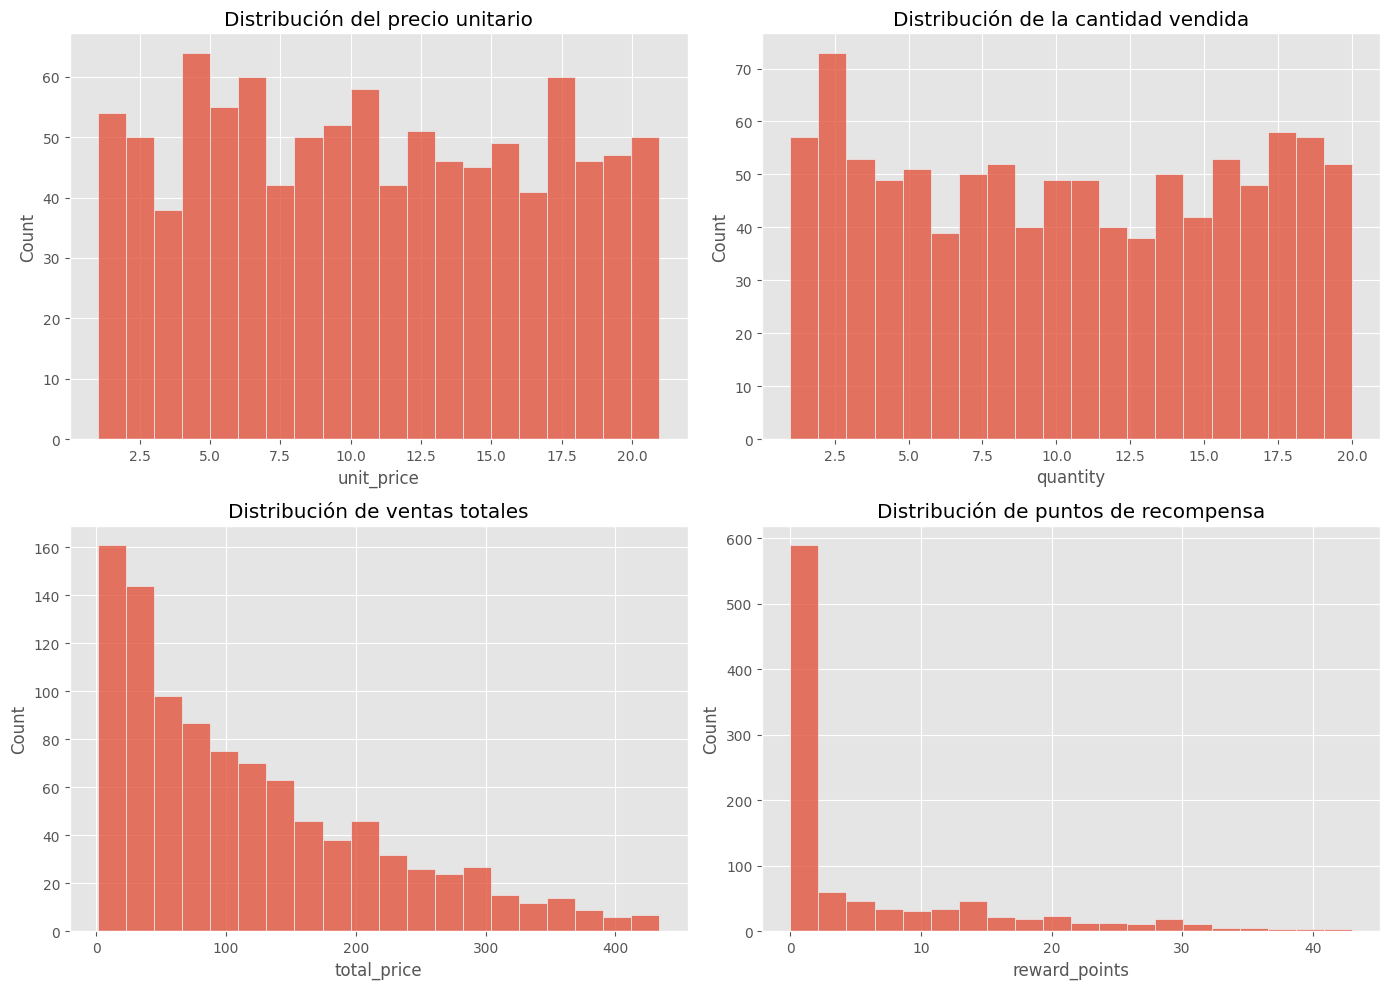

In [116]:
# ==================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['unit_price'], bins=20, ax=axes[0, 0])
axes[0, 0].set_title('Distribución del precio unitario')

sns.histplot(df['quantity'], bins=20, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de la cantidad vendida')

sns.histplot(df['total_price'], bins=20, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de ventas totales')

sns.histplot(df['reward_points'], bins=20, ax=axes[1, 1])
axes[1, 1].set_title('Distribución de puntos de recompensa')

plt.tight_layout()
plt.show()

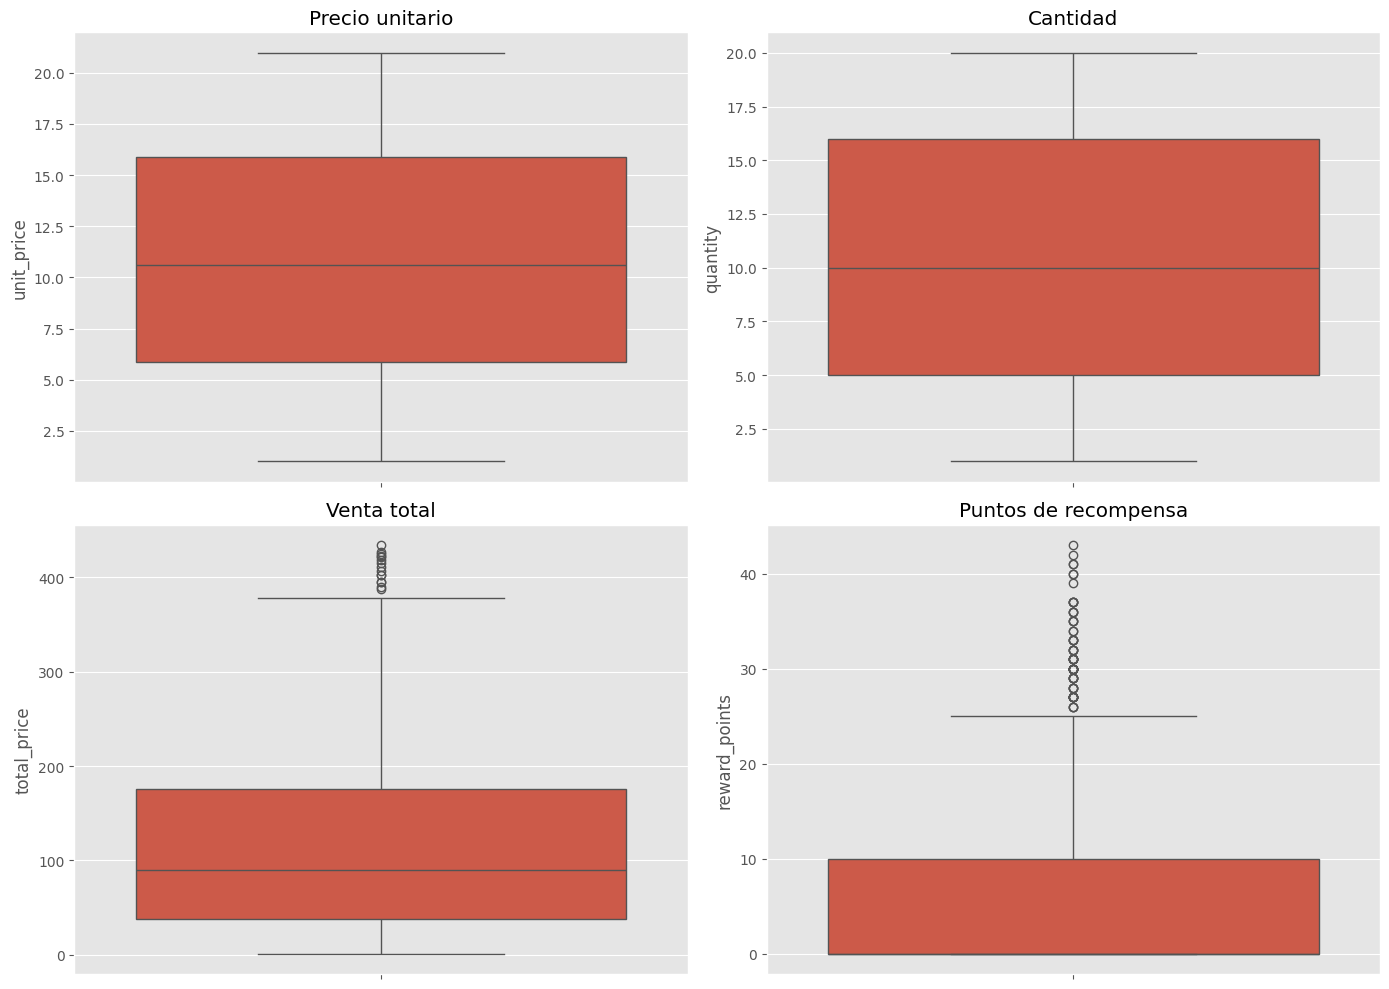

In [117]:
# ==================================================
# DETECCIÓN DE VALORES ATÍPICOS
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df['unit_price'], ax=axes[0, 0])
axes[0, 0].set_title('Precio unitario')

sns.boxplot(y=df['quantity'], ax=axes[0, 1])
axes[0, 1].set_title('Cantidad')

sns.boxplot(y=df['total_price'], ax=axes[1, 0])
axes[1, 0].set_title('Venta total')

sns.boxplot(y=df['reward_points'], ax=axes[1, 1])
axes[1, 1].set_title('Puntos de recompensa')

plt.tight_layout()
plt.show()

## Observaciones del análisis univariado

El análisis de las variables numéricas permitió identificar los siguientes patrones:

- El precio unitario presenta una distribución equilibrada y sin valores atípicos relevantes.
- La cantidad vendida muestra una distribución homogénea entre 1 y 20 unidades, sin concentraciones excesivas en valores específicos.
- La variable de ventas totales presenta una asimetría positiva, indicando que existen algunas compras de alto valor que incrementan la media general.
- Los valores extremos observados en las ventas corresponden a transacciones válidas y previamente verificadas durante la etapa de validación de negocio.
- Los puntos de recompensa presentan una fuerte concentración en valores bajos, con una mediana igual a cero y algunos casos aislados con acumulaciones considerablemente superiores.
- No se identificaron anomalías evidentes que requieran limpieza adicional o eliminación de registros.

## Conclusión del análisis univariado

Las principales variables numéricas presentan distribuciones coherentes con un contexto de ventas minoristas.

Los precios y cantidades muestran comportamientos estables y equilibrados, mientras que las ventas totales reflejan la presencia de compras de mayor volumen que incrementan el valor promedio de las transacciones.

Por su parte, los puntos de recompensa exhiben un comportamiento altamente concentrado en valores bajos, sugiriendo la existencia de patrones de acumulación asociados a determinadas compras o perfiles de clientes.

Estos hallazgos proporcionan una base sólida para continuar con análisis comparativos entre sucursales, categorías de productos y tipos de clientes.

## Análisis de negocio

En esta etapa se analizará el desempeño de las principales dimensiones comerciales presentes en el dataset.

El objetivo es identificar diferencias en ingresos, volumen de ventas y comportamiento de compra entre sucursales, ciudades, categorías de productos y segmentos de clientes.

Los resultados permitirán detectar los principales impulsores de ingresos y comprender qué factores tienen mayor impacto en las ventas del supermercado.

In [118]:
# ==================================================
# ANÁLISIS POR SUCURSAL
# ==================================================

resumen_branch = (
    df.groupby('branch', observed=True)
      .agg(
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          unidades_vendidas=('quantity', 'sum'),
          transacciones=('sale_id', 'count')
      )
      .sort_values(
          by='ventas_totales',
          ascending=False
      )
      .round(2)
)

display(resumen_branch)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
branch,,,,
A,82811.64,122.87,6982,674
B,35772.26,109.73,3355,326


In [119]:
# ==================================================
# ANÁLISIS POR CIUDAD
# ==================================================

resumen_city = (
    df.groupby('city', observed=True)
      .agg(
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          unidades_vendidas=('quantity', 'sum'),
          transacciones=('sale_id', 'count')
      )
      .sort_values(
          by='ventas_totales',
          ascending=False
      )
      .round(2)
)

display(resumen_city)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
city,,,,
Chicago,42584.71,129.04,3638,330
New York,40226.93,116.94,3344,344
Los Angeles,35772.26,109.73,3355,326


In [120]:
# ==================================================
# ANÁLISIS POR CATEGORÍA
# ==================================================

resumen_categoria = (
    df.groupby('product_category', observed=True)
      .agg(
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          unidades_vendidas=('quantity', 'sum'),
          transacciones=('sale_id', 'count')
      )
      .sort_values(
          by='ventas_totales',
          ascending=False
      )
      .round(2)
)

display(resumen_categoria.head(10))

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
product_category,,,,
Personal Care,27050.18,130.05,2278,208
Fruits,26197.45,125.35,2286,209
Beverages,22983.32,122.91,1952,187
Household,21615.84,109.17,1908,198
Stationery,20737.11,104.73,1913,198


In [121]:
# ==================================================
# ANÁLISIS POR TIPO DE CLIENTE
# ==================================================

resumen_cliente = (
    df.groupby('customer_type', observed=True)
      .agg(
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          unidades_vendidas=('quantity', 'sum'),
          transacciones=('sale_id', 'count')
      )
      .sort_values(
          by='ventas_totales',
          ascending=False
      )
      .round(2)
)

display(resumen_cliente)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
customer_type,,,,
Member,63213.63,122.51,5397,516
Normal,55370.27,114.40,4940,484


In [122]:
# ==================================================
# ANÁLISIS POR GÉNERO
# ==================================================

resumen_genero = (
    df.groupby('gender', observed=True)
      .agg(
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          unidades_vendidas=('quantity', 'sum'),
          transacciones=('sale_id', 'count')
      )
      .sort_values(
          by='ventas_totales',
          ascending=False
      )
      .round(2)
)

display(resumen_genero)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
gender,,,,
Male,64318.45,121.82,5394,528
Female,54265.45,114.97,4943,472


## Observaciones del análisis de negocio

El análisis por segmentos permitió identificar diferencias relevantes en el comportamiento de compra y generación de ingresos.

- La sucursal A concentra la mayor parte de las ventas, transacciones y unidades vendidas del dataset.
- Chicago presenta el mejor desempeño entre ciudades, registrando tanto el mayor volumen de ventas como el ticket promedio más alto.
- La categoría Personal Care lidera los ingresos totales y presenta el ticket promedio más elevado entre las categorías analizadas.
- Los clientes Member generan mayores ingresos, realizan más compras y presentan un gasto promedio superior respecto a los clientes Normal.
- Los clientes masculinos registran mayores ventas y volumen de compra que las clientas femeninas, aunque la diferencia es menor que la observada entre otros segmentos.
- Las categorías presentan un comportamiento relativamente equilibrado, sin concentraciones extremas de ventas en un único grupo de productos.

## Conclusión del análisis de negocio

Los resultados muestran que las ventas del supermercado están influenciadas principalmente por la sucursal, la ciudad y el tipo de cliente.

La sucursal A y la ciudad de Chicago destacan como los principales generadores de ingresos, mientras que la categoría Personal Care representa la línea de productos con mejor desempeño económico.

Además, los clientes pertenecientes al programa de membresía generan un mayor valor para el negocio, evidenciando un comportamiento de compra más frecuente y tickets promedio superiores.

Estos hallazgos sugieren oportunidades para fortalecer las estrategias de fidelización y replicar las prácticas comerciales observadas en los segmentos con mejor rendimiento.

## Relaciones entre variables

Después de analizar individualmente las principales variables y los distintos segmentos del negocio, se explorarán las relaciones existentes entre las métricas numéricas.

El objetivo es identificar asociaciones entre precios, cantidades, ventas y puntos de recompensa, así como detectar posibles patrones que expliquen el comportamiento de las transacciones.

Para ello se utilizarán matrices de correlación y visualizaciones de dispersión que faciliten la interpretación de las relaciones más relevantes.

In [123]:
# ==================================================
# MATRIZ DE CORRELACIÓN
# ==================================================

columnas_correlacion = [
    'unit_price',
    'quantity',
    'tax',
    'total_price',
    'reward_points'
]

correlacion = (
    df[columnas_correlacion]
    .corr(numeric_only=True)
)

display(correlacion.round(2))

,unit_price,quantity,tax,total_price,reward_points
unit_price,1.00,-0.03,0.60,0.60,0.36
quantity,-0.03,1.00,0.68,0.68,0.40
tax,0.60,0.68,1.00,1.00,0.59
total_price,0.60,0.68,1.00,1.00,0.59
reward_points,0.36,0.40,0.59,0.59,1.00


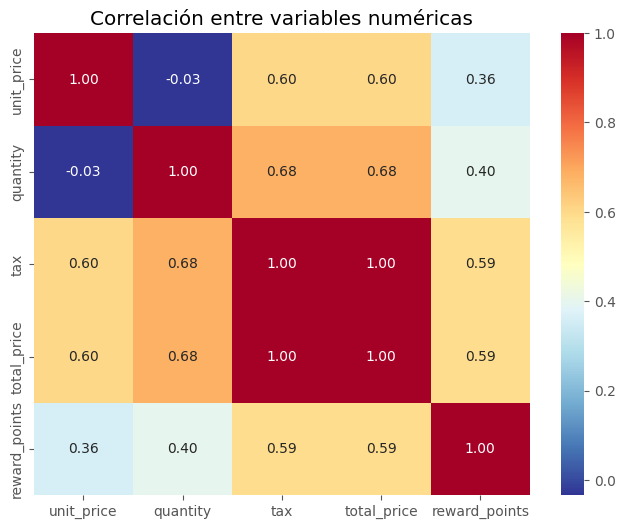

In [124]:
# ==================================================
# HEATMAP DE CORRELACIÓN
# ==================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f'
)

plt.title('Correlación entre variables numéricas')

plt.show()

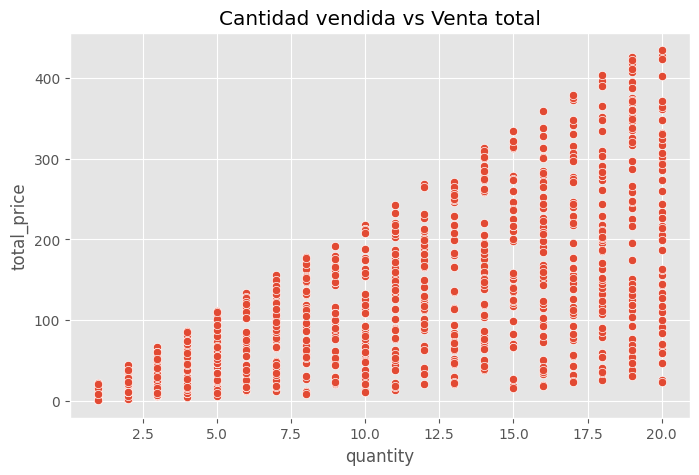

In [125]:
# ==================================================
# CANTIDAD VS VENTAS
# ==================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='quantity',
    y='total_price'
)

plt.title('Cantidad vendida vs Venta total')

plt.show()

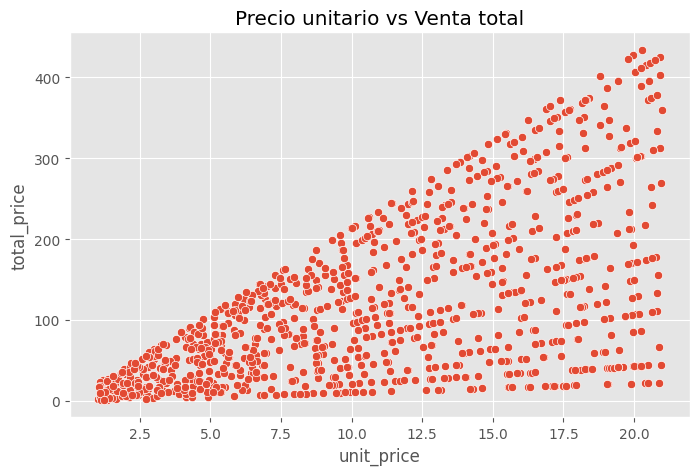

In [126]:
# ==================================================
# PRECIO UNITARIO VS VENTAS
# ==================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='unit_price',
    y='total_price'
)

plt.title('Precio unitario vs Venta total')

plt.show()

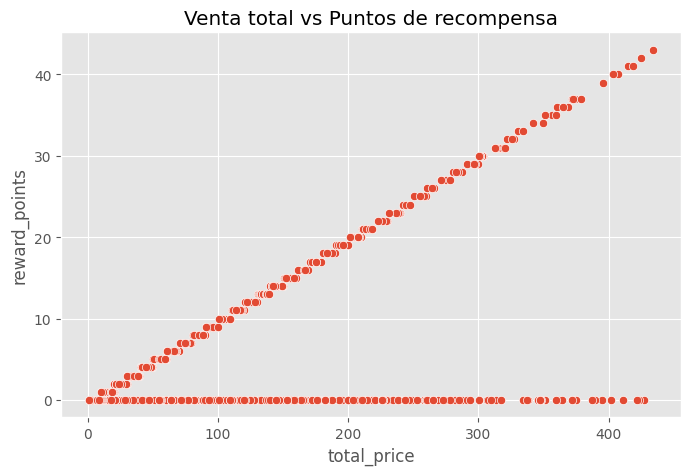

In [127]:
# ==================================================
# VENTAS VS PUNTOS DE RECOMPENSA
# ==================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='total_price',
    y='reward_points'
)

plt.title('Venta total vs Puntos de recompensa')

plt.show()

## Observaciones del análisis de correlación

El análisis de relaciones entre variables permitió identificar varios patrones relevantes:

- La cantidad vendida presenta la correlación positiva más alta con las ventas totales (0.68), indicando que el volumen de productos adquiridos es uno de los principales impulsores de ingresos.
- El precio unitario también muestra una relación positiva importante con las ventas (0.60), evidenciando que tanto el precio como la cantidad contribuyen significativamente al valor final de la transacción.
- La correlación perfecta entre tax y total_price se explica porque el impuesto forma parte directa del cálculo de la venta total.
- Los puntos de recompensa presentan una correlación positiva moderada con las ventas (0.59).
- El análisis visual sugiere que el sistema de recompensas sigue una lógica determinística, donde una parte de las transacciones no genera puntos y otra parte acumula puntos de manera proporcional al gasto realizado.
- No se identificaron relaciones negativas relevantes entre las variables analizadas.

## Conclusión del análisis de correlación

Las ventas del supermercado están influenciadas principalmente por la cantidad de productos adquiridos y, en segundo lugar, por el precio unitario de los artículos.

Asimismo, se identificó una relación consistente entre el valor de las compras y los puntos de recompensa obtenidos, lo que sugiere la existencia de un programa de fidelización estructurado y asociado al comportamiento de compra de determinados clientes.

Estos resultados proporcionan evidencia sobre los factores que impulsan los ingresos y permiten orientar análisis posteriores hacia el estudio del programa de membresía y la acumulación de recompensas.

## Análisis de fidelización y programa de recompensas

Los análisis anteriores revelaron dos hallazgos particularmente relevantes para el negocio.

Por un lado, los clientes clasificados como **Member** generan mayores ingresos, realizan más transacciones y presentan un ticket promedio superior al de los clientes **Normal**. Por otro lado, la variable **reward_points** mostró un comportamiento diferenciado, donde una parte importante de las compras no acumula puntos, mientras que otras transacciones presentan una acumulación claramente relacionada con el valor de la compra.

Además, el análisis de correlación identificó una asociación positiva entre las ventas totales y los puntos de recompensa, sugiriendo la existencia de un programa de fidelización estructurado que podría influir en el comportamiento de compra de determinados clientes.

A partir de estos resultados, resulta necesario evaluar si la membresía y la acumulación de recompensas están asociadas con una mayor contribución económica para el supermercado.

Para ello, se analizará la relación entre la membresía, la acumulación de puntos de recompensa y el desempeño comercial de los clientes, con el objetivo de evaluar el impacto potencial del programa de fidelización sobre los ingresos y el comportamiento de compra.


In [128]:
# ==================================================
# RECOMPENSAS POR TIPO DE CLIENTE
# ==================================================

resumen_reward_cliente = (
    df.groupby('customer_type', observed=True)
      .agg(
          puntos_totales=('reward_points', 'sum'),
          puntos_promedio=('reward_points', 'mean'),
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          transacciones=('sale_id', 'count')
      )
      .round(2)
)

display(resumen_reward_cliente)

,puntos_totales,puntos_promedio,ventas_totales,ticket_promedio,transacciones
customer_type,,,,,
Member,6057,11.74,63213.63,122.51,516
Normal,0,0.00,55370.27,114.40,484


In [129]:
# ==================================================
# TRANSACCIONES CON Y SIN RECOMPENSAS
# ==================================================

transacciones_con_puntos = (
    (df['reward_points'] > 0)
    .sum()
)

transacciones_sin_puntos = (
    (df['reward_points'] == 0)
    .sum()
)

porcentaje_con_puntos = (
    transacciones_con_puntos / len(df)
) * 100

print(f'Transacciones con puntos: {transacciones_con_puntos}')
print(f'Transacciones sin puntos: {transacciones_sin_puntos}')
print(f'Porcentaje con puntos: {porcentaje_con_puntos:.2f}%')

Transacciones con puntos: 493
Transacciones sin puntos: 507
Porcentaje con puntos: 49.30%


In [130]:
# ==================================================
# GASTO SEGÚN ACUMULACIÓN DE PUNTOS
# ==================================================

df['tiene_recompensa'] = np.where(
    df['reward_points'] > 0,
    'Sí',
    'No'
)

resumen_recompensa = (
    df.groupby('tiene_recompensa', observed=True)
      .agg(
          ventas_totales=('total_price', 'sum'),
          ticket_promedio=('total_price', 'mean'),
          unidades_vendidas=('quantity', 'sum'),
          transacciones=('sale_id', 'count')
      )
      .round(2)
)

display(resumen_recompensa)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
tiene_recompensa,,,,
No,55497.88,109.46,4985,507
Sí,63086.02,127.96,5352,493


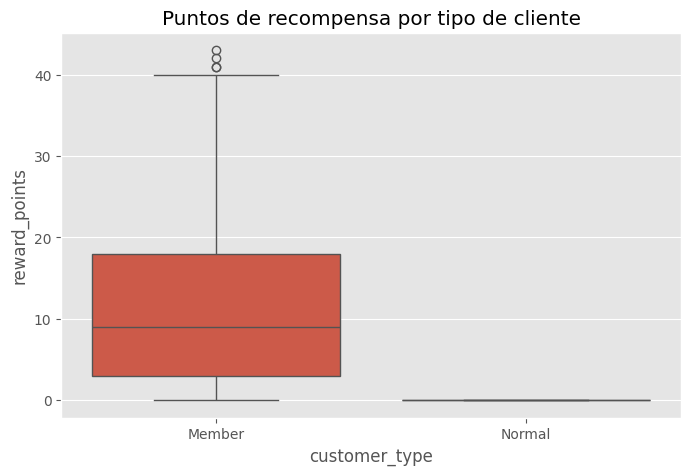

In [131]:
# ==================================================
# DISTRIBUCIÓN DE RECOMPENSAS
# ==================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='customer_type',
    y='reward_points'
)

plt.title('Puntos de recompensa por tipo de cliente')

plt.show()

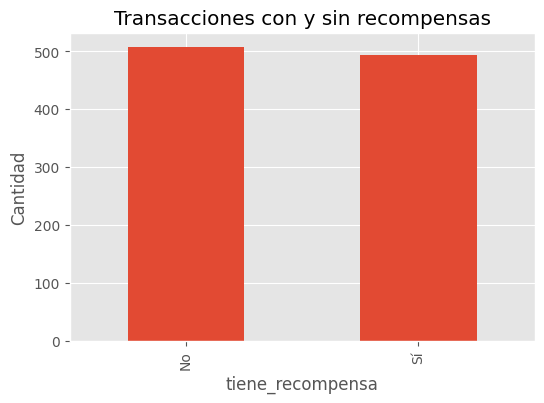

In [132]:
# ==================================================
# PARTICIPACIÓN DE TRANSACCIONES
# ==================================================

participacion = (
    df['tiene_recompensa']
    .value_counts()
)

plt.figure(figsize=(6,4))

participacion.plot(
    kind='bar'
)

plt.title('Transacciones con y sin recompensas')

plt.ylabel('Cantidad')

plt.show()

## Observaciones del análisis de fidelización

El análisis del programa de recompensas permitió identificar patrones claros entre la membresía y el comportamiento de compra.

- La totalidad de los puntos de recompensa registrados pertenece a clientes Member, mientras que los clientes Normal no acumulan puntos.
- Los clientes Member generan mayores ingresos totales, realizan más transacciones y presentan un ticket promedio superior al de los clientes Normal.
- Las transacciones asociadas a recompensas presentan un ticket promedio considerablemente más alto que aquellas que no generan puntos.
- Aproximadamente la mitad de las transacciones del dataset participan en el programa de recompensas, proporcionando una base equilibrada para la comparación entre grupos.
- La distribución de puntos observada confirma que el sistema de recompensas está directamente vinculado a la membresía y se relaciona positivamente con el valor de las compras realizadas.

## Conclusión del análisis de fidelización

Los resultados muestran que el programa de membresía está estrechamente relacionado con un mejor desempeño comercial.

Los clientes Member generan mayores ingresos, presentan tickets promedio más elevados y concentran la totalidad de los beneficios del sistema de recompensas. Asimismo, las compras que acumulan puntos registran un valor promedio superior al de las transacciones sin recompensas.

En conjunto, la evidencia sugiere que el programa de fidelización se asocia con una mayor contribución agregada de ingresos, transacciones y volumen de compra. Sin embargo, esta interpretación debe considerarse junto con la validación estadística posterior, donde se evaluará si las diferencias observadas en el gasto por transacción son significativas.

## Validación estadística del impacto de la membresía

### Hallazgos previos

Los análisis realizados hasta este punto muestran que los clientes **Member** generan mayores ingresos totales, registran un ticket promedio superior y concentran la totalidad de los beneficios asociados al programa de recompensas.

Asimismo, las transacciones vinculadas a recompensas presentan un valor promedio más elevado que aquellas que no participan en el programa, lo que sugiere una posible relación entre la fidelización y el comportamiento de compra.

### Necesidad de validación estadística

Si bien las diferencias observadas son consistentes desde una perspectiva descriptiva, resulta necesario determinar si dichas diferencias reflejan un comportamiento estructural de los clientes o si podrían atribuirse a la variabilidad natural de los datos.

La validación estadística permitirá evaluar la solidez de los hallazgos obtenidos y establecer si la membresía está asociada a diferencias significativas en el valor de las transacciones realizadas.

### Metodología

Para ello se comparará la distribución de las ventas entre clientes **Member** y **Normal** mediante pruebas estadísticas apropiadas para la naturaleza de los datos.

El análisis incluirá una evaluación preliminar de normalidad y la aplicación de una prueba de hipótesis con un nivel de significancia de 0.05, permitiendo determinar si las diferencias observadas poseen respaldo estadístico suficiente.

In [133]:
# ==================================================
# PREPARACIÓN DE MUESTRAS
# ==================================================

member_sales = df.loc[
    df['customer_type'] == 'Member',
    'total_price'
]

normal_sales = df.loc[
    df['customer_type'] == 'Normal',
    'total_price'
]

print('Registros Member:', len(member_sales))
print('Registros Normal:', len(normal_sales))

print('\nPrimeros 5 valores - Member')
display(member_sales.head())

print('\nPrimeros 5 valores - Normal')
display(normal_sales.head())

Registros Member: 516
Registros Normal: 484

Primeros 5 valores - Member


0     17.66
2     19.26
4     26.22
8    302.81
9    374.48
Name: total_price, dtype: float64


Primeros 5 valores - Normal


1     29.43
3     41.73
5    108.24
6     11.46
7    175.55
Name: total_price, dtype: float64

In [134]:
# ==================================================
# EVALUACIÓN DE NORMALIDAD
# ==================================================

member_sample = member_sales.sample(
    n=min(500, len(member_sales)),
    random_state=42
)

normal_sample = normal_sales.sample(
    n=min(500, len(normal_sales)),
    random_state=42
)

member_shapiro = shapiro(member_sample)
normal_shapiro = shapiro(normal_sample)

resultado_normalidad = pd.DataFrame({
    'grupo': ['Member', 'Normal'],
    'estadistico': [
        member_shapiro.statistic,
        normal_shapiro.statistic
    ],
    'p_value': [
        member_shapiro.pvalue,
        normal_shapiro.pvalue
    ]
})

display(resultado_normalidad.round(6))

,grupo,estadistico,p_value
0,Member,0.902813,0.0
1,Normal,0.885524,0.0


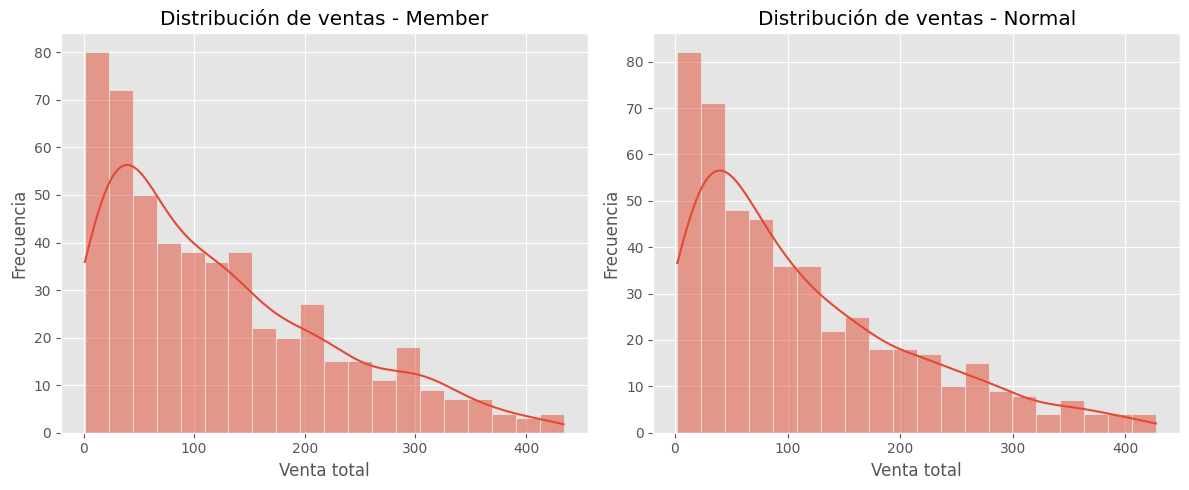

In [135]:
# ==================================================
# DISTRIBUCIÓN DE VENTAS POR TIPO DE CLIENTE
# ==================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Member
sns.histplot(
    member_sales,
    bins=20,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribución de ventas - Member')
axes[0].set_xlabel('Venta total')
axes[0].set_ylabel('Frecuencia')

# Normal
sns.histplot(
    normal_sales,
    bins=20,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distribución de ventas - Normal')
axes[1].set_xlabel('Venta total')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

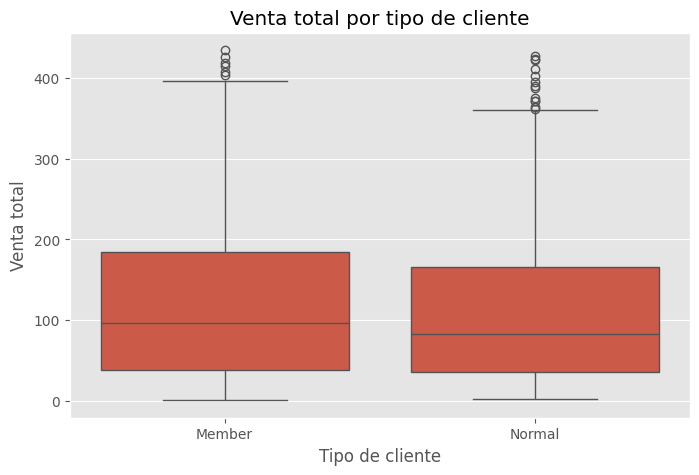

In [136]:
# ==================================================
# COMPARACIÓN DE VENTAS ENTRE GRUPOS
# ==================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='customer_type',
    y='total_price'
)

plt.title('Venta total por tipo de cliente')
plt.xlabel('Tipo de cliente')
plt.ylabel('Venta total')

plt.show()

In [137]:
# ==================================================
# PRUEBA MANN-WHITNEY U
# ==================================================

alpha = 0.05

statistic, p_value = mannwhitneyu(
    member_sales,
    normal_sales,
    alternative='two-sided'
)

print(f'Estadístico U: {statistic:.2f}')
print(f'p-value: {p_value:.10f}')

if p_value < alpha:
    
    print('\nResultado:')
    print('Se rechaza la hipótesis nula.')
    print('Existe evidencia estadística de diferencias entre ambos grupos.')

else:
    
    print('\nResultado:')
    print('No se rechaza la hipótesis nula.')
    print('No existe evidencia estadística suficiente para afirmar diferencias entre ambos grupos.')

Estadístico U: 130709.00
p-value: 0.2009924126

Resultado:
No se rechaza la hipótesis nula.
No existe evidencia estadística suficiente para afirmar diferencias entre ambos grupos.


### Conclusión

Aunque los clientes Member generan mayores ingresos agregados y registran un ticket promedio ligeramente superior, las pruebas estadísticas indican que las diferencias observadas en el valor de las transacciones no son estadísticamente significativas al nivel de confianza analizado.

Los resultados sugieren que la membresía está asociada principalmente a una mayor participación dentro del conjunto de transacciones, pero no necesariamente a un comportamiento de gasto individual sustancialmente distinto respecto a los clientes Normal.

En consecuencia, el programa de fidelización parece contribuir al volumen de actividad comercial, aunque no se observa evidencia suficiente para concluir que incrementa significativamente el importe de cada compra realizada.

## Análisis estratégico de productos y categorías

### Hallazgos previos

Los análisis realizados muestran que las diferencias observadas entre clientes Member y Normal no son estadísticamente significativas en términos de gasto por transacción. Aunque los clientes Member generan mayores ingresos agregados, dicho comportamiento parece estar asociado principalmente a una mayor participación en el volumen de compras y no a un gasto individual significativamente superior.

### Necesidad analítica

Una vez comprendido el comportamiento de los clientes, resulta necesario identificar los productos y categorías que impulsan el desempeño comercial del supermercado.

Determinar qué categorías generan mayores ingresos, cuáles presentan mayor volumen de ventas y qué productos contribuyen en mayor medida a la facturación permitirá detectar oportunidades de crecimiento, optimización del inventario y estrategias comerciales más efectivas.

### Metodología

Se realizará un análisis agregado de categorías y productos considerando indicadores como ventas totales, unidades vendidas, ticket promedio y participación sobre la facturación total.

Posteriormente se visualizarán los resultados para identificar los segmentos con mayor relevancia comercial y aquellos con potencial de mejora.

In [138]:
# ==================================================
# VENTAS POR CATEGORÍA
# ==================================================

ventas_categoria = (
    df.groupby('product_category', observed=True)
    .agg(
        ventas_totales=('total_price', 'sum'),
        unidades_vendidas=('quantity', 'sum'),
        ticket_promedio=('total_price', 'mean'),
        transacciones=('sale_id', 'count')
    )
    .sort_values(
        by='ventas_totales',
        ascending=False
    )
    .round(2)
)

display(ventas_categoria)

,ventas_totales,unidades_vendidas,ticket_promedio,transacciones
product_category,,,,
Personal Care,27050.18,2278,130.05,208
Fruits,26197.45,2286,125.35,209
Beverages,22983.32,1952,122.91,187
Household,21615.84,1908,109.17,198
Stationery,20737.11,1913,104.73,198


In [139]:
# ==================================================
# PARTICIPACIÓN POR CATEGORÍA
# ==================================================

participacion_categoria = ventas_categoria.copy()

participacion_categoria['participacion_%'] = (
    participacion_categoria['ventas_totales']
    / participacion_categoria['ventas_totales'].sum()
    * 100
)

display(
    participacion_categoria[
        ['ventas_totales', 'participacion_%']
    ].round(2)
)

,ventas_totales,participacion_%
product_category,,
Personal Care,27050.18,22.81
Fruits,26197.45,22.09
Beverages,22983.32,19.38
Household,21615.84,18.23
Stationery,20737.11,17.49


In [140]:
# ==================================================
# TOP 10 PRODUCTOS POR FACTURACIÓN
# ==================================================

top_productos = (
    df.groupby('product_name', observed=True)
    .agg(
        ventas_totales=('total_price', 'sum'),
        unidades_vendidas=('quantity', 'sum'),
        ticket_promedio=('total_price', 'mean'),
        transacciones=('sale_id', 'count')
    )
    .sort_values(
        by='ventas_totales',
        ascending=False
    )
    .head(10)
    .round(2)
)

display(top_productos)

,ventas_totales,unidades_vendidas,ticket_promedio,transacciones
product_name,,,,
Shampoo,27041.36,2238,120.72,224
Notebook,24792.98,2165,127.80,194
Orange Juice,24686.46,2183,118.68,208
Detergent,22449.07,2010,118.78,189
Apple,19614.03,1741,106.02,185


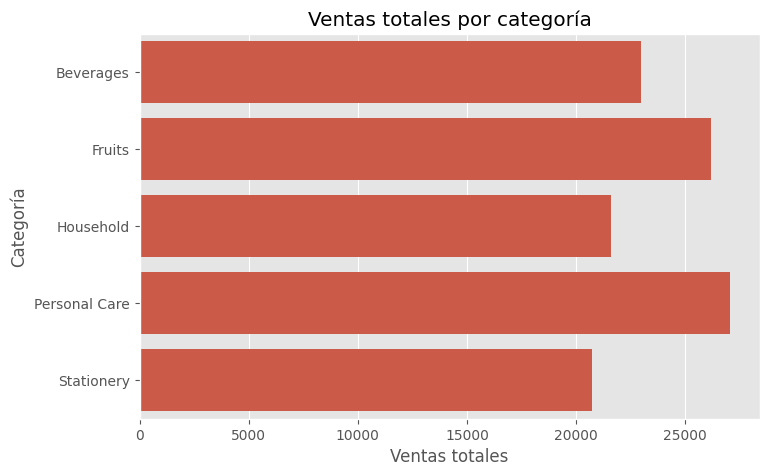

In [141]:
# ==================================================
# CATEGORÍAS CON MAYOR FACTURACIÓN
# ==================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=ventas_categoria.reset_index(),
    x='ventas_totales',
    y='product_category'
)

plt.title('Ventas totales por categoría')
plt.xlabel('Ventas totales')
plt.ylabel('Categoría')

plt.show()

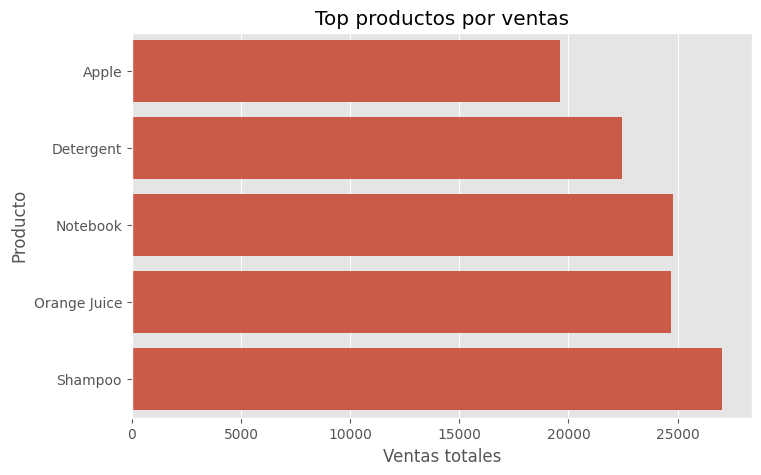

In [142]:
# ==================================================
# TOP PRODUCTOS POR FACTURACIÓN
# ==================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_productos.reset_index(),
    x='ventas_totales',
    y='product_name'
)

plt.title('Top productos por ventas')
plt.xlabel('Ventas totales')
plt.ylabel('Producto')

plt.show()

### Conclusión

El análisis de productos y categorías muestra una estructura comercial equilibrada, donde la facturación se distribuye de manera relativamente homogénea entre las distintas líneas de negocio.

Las categorías Personal Care y Fruits representan los principales motores de ingresos del supermercado, combinando altos niveles de facturación con tickets promedio superiores al resto de las categorías analizadas.

A nivel de producto, Shampoo destaca como el artículo con mayor contribución económica, seguido por Notebook y Orange Juice, consolidándose como productos estratégicos dentro del portafolio comercial.

Los resultados sugieren que la organización cuenta con una cartera diversificada y estable, aunque existen oportunidades para fortalecer la participación de las categorías Household y Stationery mediante estrategias de promoción, fidelización o incremento del ticket promedio.

## Análisis del impacto del precio y volumen de ventas

### Hallazgos previos

El análisis de categorías mostró que Personal Care y Fruits concentran la mayor proporción de ingresos del supermercado, mientras que Shampoo, Notebook y Orange Juice destacan como los productos con mayor facturación.

Asimismo, se observó que las categorías líderes presentan tickets promedio superiores al resto de segmentos analizados.

### Necesidad analítica

La facturación de una categoría puede estar impulsada por distintos factores. Un alto volumen de ingresos puede originarse por vender una gran cantidad de unidades, por comercializar productos de mayor valor o por una combinación de ambos elementos.

Comprender qué variable explica mejor el desempeño comercial permitirá identificar oportunidades de crecimiento y definir estrategias enfocadas en volumen, precio o posicionamiento de producto.

### Metodología

Se evaluará la relación entre precio unitario, cantidad vendida y ventas totales mediante análisis descriptivos y visualizaciones comparativas.

Posteriormente se analizará el desempeño promedio de cada categoría para identificar los principales impulsores de ingresos dentro del portafolio comercial.

In [143]:
# ==================================================
# PRECIO VS VOLUMEN POR CATEGORÍA
# ==================================================

resumen_categoria_detallado = (
    df.groupby('product_category', observed=True)
    .agg(
        precio_promedio=('unit_price', 'mean'),
        unidades_vendidas=('quantity', 'sum'),
        ventas_totales=('total_price', 'sum'),
        ticket_promedio=('total_price', 'mean')
    )
    .round(2)
)

display(resumen_categoria_detallado)

,precio_promedio,unidades_vendidas,ventas_totales,ticket_promedio
product_category,,,,
Beverages,11.11,1952,22983.32,122.91
Fruits,10.85,2286,26197.45,125.35
Household,10.93,1908,21615.84,109.17
Personal Care,11.25,2278,27050.18,130.05
Stationery,10.04,1913,20737.11,104.73


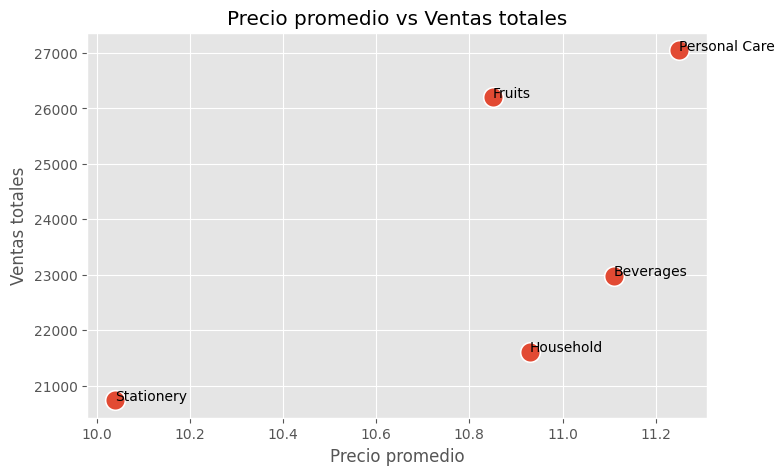

In [144]:
# ==================================================
# PRECIO PROMEDIO VS VENTAS TOTALES
# ==================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=resumen_categoria_detallado.reset_index(),
    x='precio_promedio',
    y='ventas_totales',
    s=200
)

for _, fila in resumen_categoria_detallado.reset_index().iterrows():
    
    plt.text(
        fila['precio_promedio'],
        fila['ventas_totales'],
        fila['product_category']
    )

plt.title('Precio promedio vs Ventas totales')
plt.xlabel('Precio promedio')
plt.ylabel('Ventas totales')

plt.show()

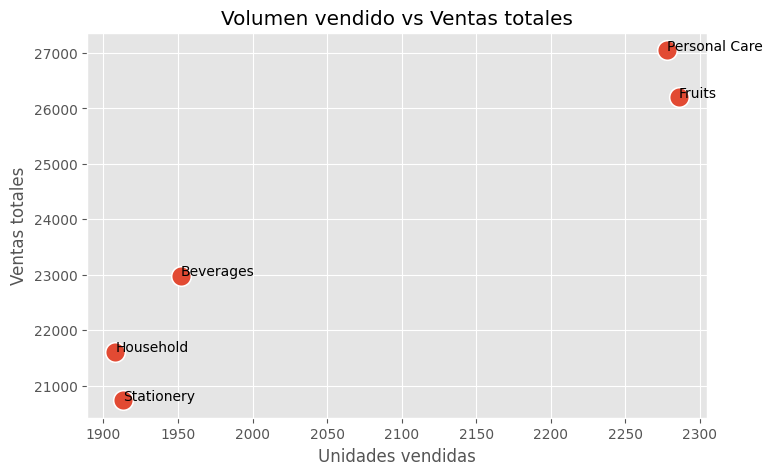

In [145]:
# ==================================================
# UNIDADES VENDIDAS VS VENTAS TOTALES
# ==================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=resumen_categoria_detallado.reset_index(),
    x='unidades_vendidas',
    y='ventas_totales',
    s=200
)

for _, fila in resumen_categoria_detallado.reset_index().iterrows():
    
    plt.text(
        fila['unidades_vendidas'],
        fila['ventas_totales'],
        fila['product_category']
    )

plt.title('Volumen vendido vs Ventas totales')
plt.xlabel('Unidades vendidas')
plt.ylabel('Ventas totales')

plt.show()

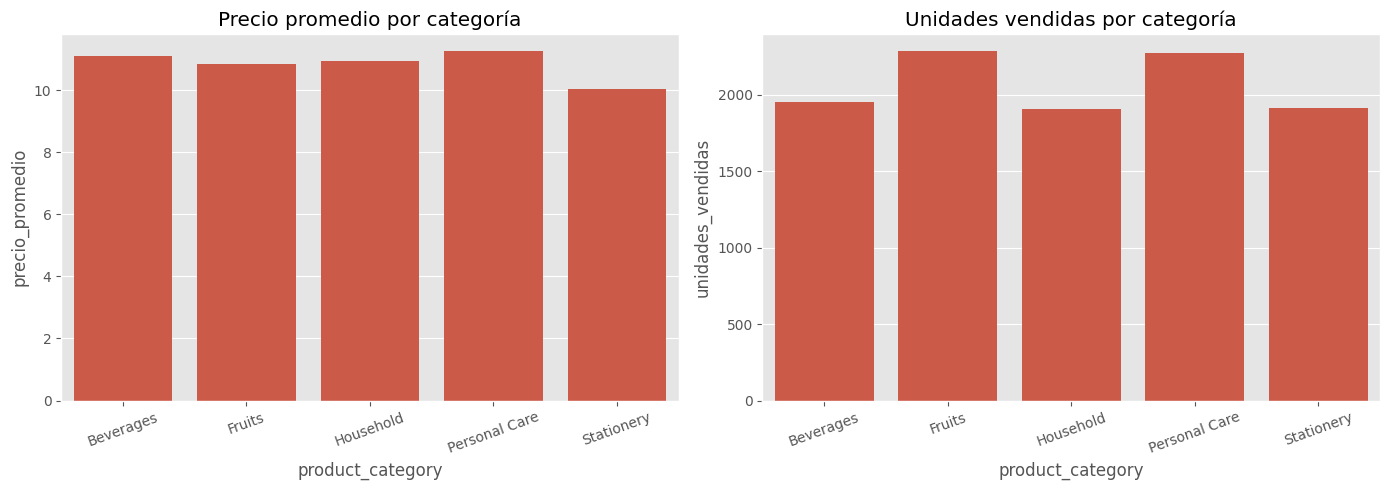

In [146]:
# ==================================================
# COMPARACIÓN DE INDICADORES POR CATEGORÍA
# ==================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

sns.barplot(
    data=resumen_categoria_detallado.reset_index(),
    x='product_category',
    y='precio_promedio',
    ax=axes[0]
)

axes[0].set_title('Precio promedio por categoría')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=resumen_categoria_detallado.reset_index(),
    x='product_category',
    y='unidades_vendidas',
    ax=axes[1]
)

axes[1].set_title('Unidades vendidas por categoría')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Conclusión

El análisis del impacto del precio y volumen revela que el desempeño comercial de las categorías está explicado principalmente por la cantidad de unidades vendidas y no por diferencias significativas en los precios promedio.

Las categorías Personal Care y Fruits lideran tanto el volumen de ventas como la facturación total, lo que indica que su éxito comercial se sustenta en una demanda elevada y constante.

Por otro lado, las diferencias de precio promedio entre categorías son relativamente pequeñas, limitando su capacidad para explicar por sí solas las variaciones observadas en ingresos.

Estos resultados sugieren que las estrategias de crecimiento deberían enfocarse prioritariamente en incrementar la rotación y frecuencia de compra de los productos con mayor demanda, manteniendo al mismo tiempo una política de precios competitiva.

## Análisis de segmentación comercial

### Hallazgos previos

Los análisis anteriores identificaron que las categorías Personal Care y Fruits lideran la facturación del supermercado, mientras que Shampoo, Notebook y Orange Juice destacan entre los productos con mayor contribución económica.

Asimismo, se observó que el volumen de unidades vendidas explica mejor el comportamiento de las ventas que las diferencias de precio entre categorías.

### Necesidad analítica

Comprender el desempeño global del negocio resulta insuficiente para identificar oportunidades específicas de crecimiento. Es necesario analizar cómo se distribuyen las ventas entre los distintos segmentos de clientes y mercados atendidos por el supermercado.

La identificación de patrones asociados a ubicación geográfica, género y tipo de cliente permitirá detectar segmentos con mayor potencial comercial y áreas donde podrían implementarse estrategias de expansión o fidelización.

### Metodología

Se realizará un análisis segmentado considerando ciudad, género y tipo de cliente. Para cada segmento se evaluarán indicadores como ventas totales, ticket promedio, volumen vendido y cantidad de transacciones.

Posteriormente se utilizarán visualizaciones comparativas para identificar los grupos que contribuyen en mayor medida al desempeño comercial de la organización.

In [147]:
# ==================================================
# SEGMENTACIÓN POR CIUDAD
# ==================================================

segmento_ciudad = (
    df.groupby('city', observed=True)
    .agg(
        ventas_totales=('total_price', 'sum'),
        ticket_promedio=('total_price', 'mean'),
        unidades_vendidas=('quantity', 'sum'),
        transacciones=('sale_id', 'count')
    )
    .sort_values(
        by='ventas_totales',
        ascending=False
    )
    .round(2)
)

display(segmento_ciudad)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
city,,,,
Chicago,42584.71,129.04,3638,330
New York,40226.93,116.94,3344,344
Los Angeles,35772.26,109.73,3355,326


In [148]:
# ==================================================
# SEGMENTACIÓN POR GÉNERO
# ==================================================

segmento_genero = (
    df.groupby('gender', observed=True)
    .agg(
        ventas_totales=('total_price', 'sum'),
        ticket_promedio=('total_price', 'mean'),
        unidades_vendidas=('quantity', 'sum'),
        transacciones=('sale_id', 'count')
    )
    .sort_values(
        by='ventas_totales',
        ascending=False
    )
    .round(2)
)

display(segmento_genero)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
gender,,,,
Male,64318.45,121.82,5394,528
Female,54265.45,114.97,4943,472


In [149]:
# ==================================================
# SEGMENTACIÓN POR TIPO DE CLIENTE
# ==================================================

segmento_cliente = (
    df.groupby('customer_type', observed=True)
    .agg(
        ventas_totales=('total_price', 'sum'),
        ticket_promedio=('total_price', 'mean'),
        unidades_vendidas=('quantity', 'sum'),
        transacciones=('sale_id', 'count')
    )
    .sort_values(
        by='ventas_totales',
        ascending=False
    )
    .round(2)
)

display(segmento_cliente)

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
customer_type,,,,
Member,63213.63,122.51,5397,516
Normal,55370.27,114.40,4940,484


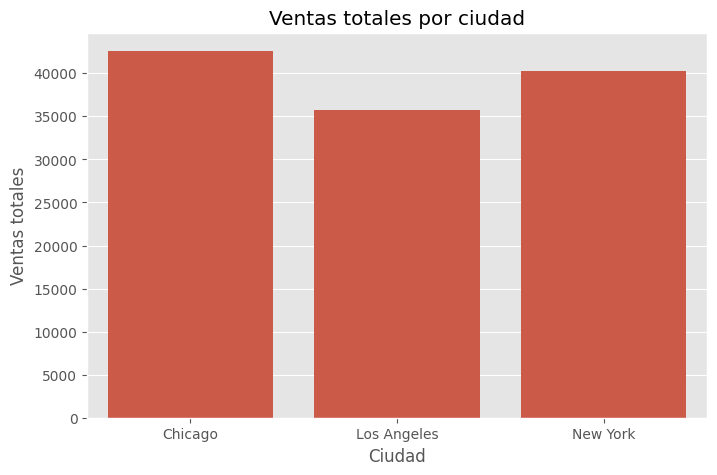

In [150]:
# ==================================================
# VENTAS POR CIUDAD
# ==================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=segmento_ciudad.reset_index(),
    x='city',
    y='ventas_totales'
)

plt.title('Ventas totales por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Ventas totales')

plt.show()

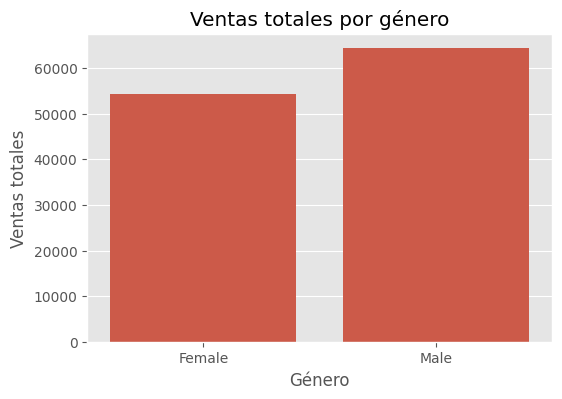

In [151]:
# ==================================================
# VENTAS POR GÉNERO
# ==================================================

plt.figure(figsize=(6,4))

sns.barplot(
    data=segmento_genero.reset_index(),
    x='gender',
    y='ventas_totales'
)

plt.title('Ventas totales por género')
plt.xlabel('Género')
plt.ylabel('Ventas totales')

plt.show()

In [152]:
# ==================================================
# CATEGORÍAS POR CIUDAD
# ==================================================

ventas_ciudad_categoria = (
    df.pivot_table(
        values='total_price',
        index='city',
        columns='product_category',
        aggfunc='sum'
    )
    .round(2)
)

display(ventas_ciudad_categoria)

product_category,Beverages,Fruits,Household,Personal Care,Stationery
city,,,,,
Chicago,6431.42,9716.12,8116.01,8510.49,9810.67
Los Angeles,8044.45,8864.57,6358.20,8364.01,4141.03
New York,8507.45,7616.76,7141.63,10175.68,6785.41


### Observaciones

Chicago es la ciudad con mejor desempeño comercial, liderando tanto las ventas totales como el ticket promedio. Aunque New York registra un volumen similar de operaciones, las compras realizadas en Chicago generan un mayor valor económico por transacción.

Los clientes de género masculino presentan mayores niveles de gasto y facturación acumulada respecto al segmento femenino, aunque ambos grupos mantienen una participación relativamente equilibrada dentro de la operación.

La segmentación por tipo de cliente confirma la relevancia estratégica del programa de fidelización. Los clientes Member generan mayores ventas totales, un ticket promedio superior y un mayor volumen de productos adquiridos, consolidándose como un segmento de alta contribución agregada para el negocio.

A nivel geográfico se observan diferencias en las preferencias de compra. Chicago muestra una demanda diversificada entre varias categorías, Los Angeles concentra una mayor proporción de ventas en productos de consumo recurrente, mientras que New York destaca especialmente en la categoría Personal Care.

### Conclusión

Los resultados sugieren que el crecimiento futuro del supermercado puede apoyarse en dos factores principales: fortalecer los programas de fidelización para incrementar la participación de clientes Member y adaptar las estrategias comerciales a las preferencias específicas de cada ciudad. Ambos enfoques tienen potencial para aumentar tanto el volumen de ventas como el valor promedio de cada transacción.

## Análisis de patrones de compra

## Hallazgos previos

Los análisis anteriores mostraron diferencias relevantes entre ciudades, categorías de productos y segmentos de clientes. Asimismo, se identificó que los clientes Member generan mayores ingresos, presentan tickets promedio más altos y concentran la totalidad de los puntos de recompensa otorgados por el programa de fidelización.

## Necesidad analítica

Una vez identificados los segmentos con mejor desempeño comercial, resulta necesario comprender cómo se generan las ventas dentro de cada transacción. Analizar los patrones de compra permitirá identificar qué factores influyen en el valor final de las ventas y cuáles son las características de las operaciones de mayor impacto económico.

## Metodología

Se evaluará la relación entre el volumen adquirido y el gasto realizado por los clientes, así como el comportamiento de compra según género y tipo de cliente. Adicionalmente, se examinarán las transacciones de mayor valor para identificar patrones asociados a compras de alto rendimiento.

## Análisis

Se estudiará la distribución de las ventas, la relación entre cantidad comprada y gasto total, y el comportamiento de los principales segmentos de clientes mediante estadísticas descriptivas y visualizaciones comparativas.

## Objetivo

Identificar los factores que impulsan las ventas más elevadas y comprender cómo distintos perfiles de clientes contribuyen a los ingresos del supermercado.

In [153]:
# ==================================================
# DISTRIBUCIÓN DE TICKETS DE COMPRA
# ==================================================

q1 = df['total_price'].quantile(0.25)
q3 = df['total_price'].quantile(0.75)

print('Primer cuartil (25%):', round(q1, 2))
print('Tercer cuartil (75%):', round(q3, 2))

df['tipo_ticket'] = np.where(
    df['total_price'] >= q3,
    'Alto',
    np.where(
        df['total_price'] <= q1,
        'Bajo',
        'Medio'
    )
)

display(
    df['tipo_ticket']
    .value_counts()
    .to_frame('cantidad')
)

Primer cuartil (25%): 38.38
Tercer cuartil (75%): 176.07


,cantidad
tipo_ticket,
Medio,500
Bajo,250
Alto,250


In [154]:
# ==================================================
# PERFIL DE TRANSACCIONES DE ALTO VALOR
# ==================================================

tickets_altos = (
    df[df['tipo_ticket'] == 'Alto']
    .groupby('product_category', observed=True)
    .agg(
        ventas_totales=('total_price', 'sum'),
        ticket_promedio=('total_price', 'mean'),
        unidades_vendidas=('quantity', 'sum'),
        transacciones=('sale_id', 'count')
    )
    .sort_values(
        by='ventas_totales',
        ascending=False
    )
    .round(2)
)

display(tickets_altos.head(10))

,ventas_totales,ticket_promedio,unidades_vendidas,transacciones
product_category,,,,
Personal Care,16714.39,257.14,1036,65
Fruits,15184.60,261.80,936,58
Beverages,13564.43,276.83,795,49
Household,11218.55,254.97,660,44
Stationery,9584.99,281.91,558,34


,ticket_promedio
gender,
Female,114.97
Male,121.82


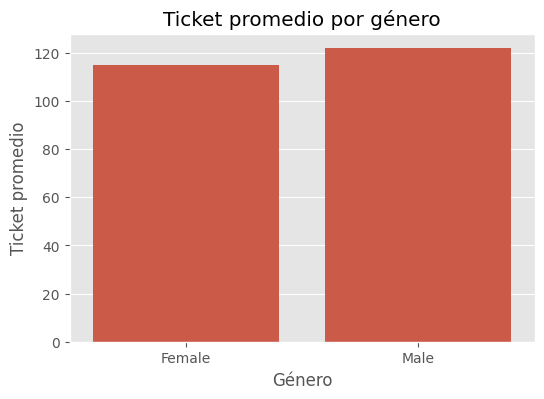

In [155]:
# ==================================================
# TICKET PROMEDIO POR GÉNERO
# ==================================================

ticket_genero = (
    df.groupby('gender', observed=True)
    .agg(
        ticket_promedio=('total_price', 'mean')
    )
    .round(2)
)

display(ticket_genero)

plt.figure(figsize=(6,4))

sns.barplot(
    data=ticket_genero.reset_index(),
    x='gender',
    y='ticket_promedio'
)

plt.title('Ticket promedio por género')
plt.xlabel('Género')
plt.ylabel('Ticket promedio')

plt.show()

,ticket_promedio
customer_type,
Member,122.51
Normal,114.40


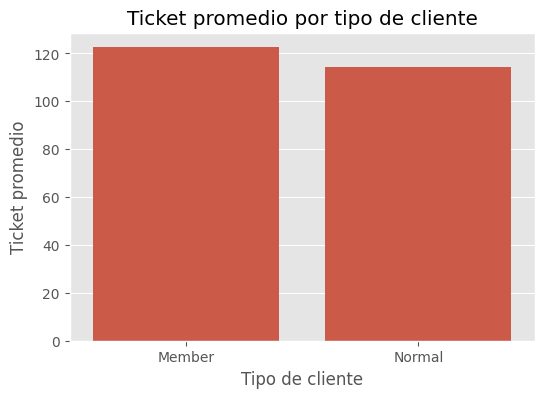

In [156]:
# ==================================================
# TICKET PROMEDIO POR TIPO DE CLIENTE
# ==================================================

ticket_cliente = (
    df.groupby('customer_type', observed=True)
    .agg(
        ticket_promedio=('total_price', 'mean')
    )
    .round(2)
)

display(ticket_cliente)

plt.figure(figsize=(6,4))

sns.barplot(
    data=ticket_cliente.reset_index(),
    x='customer_type',
    y='ticket_promedio'
)

plt.title('Ticket promedio por tipo de cliente')
plt.xlabel('Tipo de cliente')
plt.ylabel('Ticket promedio')

plt.show()

Correlación cantidad vs venta: 0.684


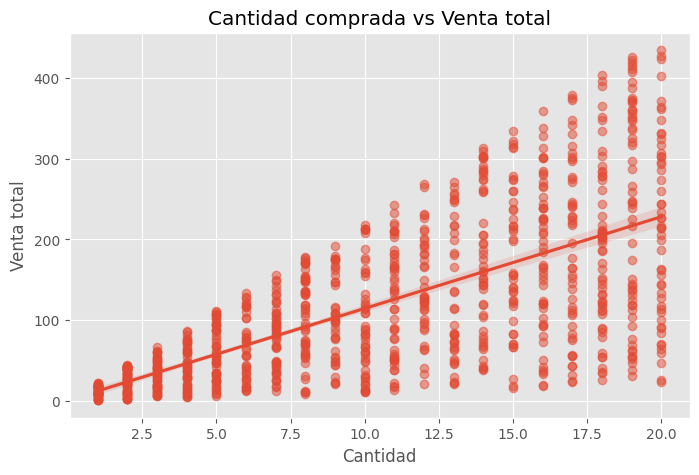

In [157]:
# ==================================================
# RELACIÓN ENTRE CANTIDAD Y GASTO
# ==================================================

correlacion_cantidad_venta = (
    df['quantity']
    .corr(df['total_price'])
)

print(
    'Correlación cantidad vs venta:',
    round(correlacion_cantidad_venta, 3)
)

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='quantity',
    y='total_price',
    scatter_kws={'alpha':0.5}
)

plt.title('Cantidad comprada vs Venta total')
plt.xlabel('Cantidad')
plt.ylabel('Venta total')

plt.show()

### Observaciones

La clasificación de tickets de compra permitió identificar que el 25% de las transacciones de mayor valor supera los 176.07 en ventas totales. Dentro de este segmento, la categoría Personal Care concentra la mayor facturación, seguida por Fruits y Beverages, lo que indica que estas líneas de producto participan activamente en la generación de compras de alto valor.

El análisis por género muestra que los clientes masculinos presentan un ticket promedio ligeramente superior al de las clientes femeninas. No obstante, la diferencia observada es moderada y ambos segmentos mantienen una participación relevante dentro de la operación comercial.

Los clientes Member continúan mostrando indicadores superiores de desempeño, registrando mayores niveles de gasto promedio por transacción respecto a los clientes Normal. Este comportamiento es consistente con los resultados obtenidos durante el análisis de fidelización.

La relación entre cantidad adquirida y venta total presenta una correlación positiva moderadamente fuerte (0.684), evidenciando que el volumen de productos comprados constituye uno de los principales impulsores de los ingresos del supermercado.

### Conclusión

Los resultados sugieren que el crecimiento de las ventas está estrechamente relacionado con el incremento del volumen adquirido por transacción. Las categorías Personal Care y Fruits destacan como los principales motores de facturación dentro de las compras de alto valor, mientras que los clientes fidelizados mantienen una contribución agregada relevante para el negocio. Estos hallazgos respaldan estrategias orientadas a incentivar compras de mayor volumen y fortalecer los programas de fidelización para maximizar los ingresos del negocio.

# Conclusión general del proyecto

## Resumen ejecutivo

El presente análisis tuvo como objetivo comprender el comportamiento de ventas de un supermercado mediante el estudio de transacciones, clientes, productos y patrones de compra. A través de técnicas de análisis exploratorio de datos se identificaron los principales factores asociados al desempeño comercial y a la generación de ingresos.

## Calidad y preparación de los datos

La fase inicial confirmó que el conjunto de datos presentaba una estructura adecuada para el análisis. No se identificaron valores nulos, registros duplicados ni inconsistencias en los cálculos de ventas. Asimismo, la optimización de tipos de datos permitió reducir significativamente el consumo de memoria sin afectar la integridad de la información.

## Principales hallazgos comerciales

### Desempeño por sucursal y ciudad

La sucursal A concentró la mayor parte de las ventas totales, el mayor volumen de productos vendidos y el ticket promedio más alto. A nivel geográfico, Chicago se posicionó como la ciudad con mejor desempeño comercial, liderando tanto los ingresos como el valor promedio por transacción.

Estos resultados sugieren la existencia de diferencias regionales en los hábitos de compra y oportunidades para adaptar estrategias comerciales según cada mercado.

### Categorías y productos con mayor facturación

La categoría Personal Care registró la mayor facturación total del negocio, seguida por Fruits y Beverages. De manera consistente, Shampoo se consolidó como el producto con mayor facturación acumulada.

Los resultados muestran que el crecimiento de los ingresos se encuentra impulsado principalmente por categorías de consumo recurrente que mantienen simultáneamente altos niveles de demanda y valores de compra elevados.

### Programa de fidelización

Los clientes Member generaron mayores ingresos, registraron tickets promedio superiores y adquirieron un mayor volumen de productos respecto a los clientes Normal.

Aunque la prueba estadística aplicada no encontró evidencia suficiente para afirmar diferencias significativas entre las distribuciones de gasto de ambos grupos, los indicadores operativos muestran una contribución consistentemente superior por parte de los clientes fidelizados.

Este comportamiento respalda la importancia estratégica de los programas de fidelización como mecanismo para incrementar la contribución agregada de los clientes al negocio.

### Comportamiento de compra

El análisis reveló una correlación positiva moderadamente fuerte entre la cantidad de productos adquiridos y las ventas totales (0.684), indicando que el volumen de compra constituye uno de los principales impulsores de los ingresos del supermercado.

Las transacciones de alto valor se concentraron principalmente en las categorías Personal Care y Fruits, lo que sugiere que estas líneas de producto desempeñan un papel fundamental en la generación de tickets elevados.

Asimismo, los clientes masculinos mostraron un gasto promedio ligeramente superior al de las clientes femeninas, aunque ambos segmentos mantienen una participación relevante dentro de la operación comercial.

## Recomendaciones de negocio

Con base en los resultados obtenidos, se identifican las siguientes oportunidades de mejora:

- Fortalecer las estrategias de fidelización para incrementar la participación de clientes Member.
- Diseñar promociones orientadas a aumentar la cantidad de productos adquiridos por transacción.
- Priorizar acciones comerciales sobre las categorías Personal Care y Fruits debido a su elevada contribución a los ingresos.
- Analizar las prácticas comerciales implementadas en Chicago para identificar oportunidades de replicación en otras ciudades.
- Implementar campañas segmentadas según ciudad y perfil de cliente para maximizar la efectividad de las acciones de marketing.

## Conclusión final

Los resultados demuestran que las ventas del supermercado están influenciadas principalmente por el volumen adquirido por transacción, la participación de clientes fidelizados y el desempeño de categorías estratégicas como Personal Care y Fruits. La combinación de programas de fidelización efectivos, estrategias de incremento de ticket promedio y una gestión comercial adaptada a las características de cada mercado representa una oportunidad significativa para impulsar el crecimiento sostenido de los ingresos y mejorar el rendimiento general del negocio.

# Principales insights

1. Chicago generó el mayor volumen de ingresos y el ticket promedio más alto.
2. Personal Care fue la categoría con mayor facturación del negocio.
3. Shampoo se posicionó como el producto con mayor facturación acumulada.
4. Los clientes Member registraron mayores ingresos agregados, más transacciones y mayor volumen de compra.
5. La cantidad de productos adquiridos mostró una correlación positiva de 0.684 con las ventas totales.
6. Las compras de alto valor se concentraron principalmente en Personal Care y Fruits.